# UG-CPPO: Uncertainty-Gated LLM Infusion for Risk-Sensitive Trading Agents
**FinAI Contest 2025 — Task 1** · Grace Esther · Société Générale

---
### 3 bugs corrigés vs. version précédente
| Bug | Symptôme | Fix |
|-----|----------|-----|
| Cell 4b: `.count(0)` sur arrays | `ValueError: truth value ambiguous` | Remplacé par stats numpy |
| `signal_df=None` → agents identiques | 3 courbes superposées | Mock signals générés si FNSPID absent |
| 50k steps → agents passifs | Actions ≈ 0, courbes plates | Réduit à 20 tickers + 200k steps + reward scaling |


## 0a. Install & Setup

In [1]:
%%capture
!pip install finrl stable-baselines3[extra] gymnasium yfinance stockstats
!pip install openai anthropic python-dotenv pyyaml tqdm pyfolio-reloaded huggingface_hub

In [2]:
import os, sys
from pathlib import Path

REPO_URL = 'https://github.com/graceesthi/ug_cppo.git'

current = Path.cwd()
project_root = None
if (current / 'src').exists():
    project_root = current
elif (current.parent / 'src').exists():
    project_root = current.parent

if project_root:
    os.chdir(project_root)
    print(f'✓ Project found at: {project_root}')
else:
    if not Path('ug_cppo').exists():
        print(f'Cloning {REPO_URL}...')
        os.system(f'git clone {REPO_URL}')
    os.chdir('ug_cppo')
    project_root = Path.cwd()

sys.path.insert(0, str(project_root))
os.makedirs('data', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
os.makedirs('results/tensorboard', exist_ok=True)
print(f'Working from: {os.getcwd()}')

✓ Project found at: /Users/grace/Downloads/ug_cppo
Working from: /Users/grace/Downloads/ug_cppo


## 0b. Configure LLM provider

In [3]:
LLM_PROVIDER = 'openai'   # 'mock' | 'openai' | 'anthropic'

from dotenv import load_dotenv
load_dotenv(dotenv_path=Path(project_root) / '.env')

if LLM_PROVIDER == 'openai':
    api_key = os.environ.get('OPENAI_API_KEY', '')
    if not api_key:
        # Colab fallback
        try:
            from google.colab import userdata
            os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
        except Exception:
            raise ValueError('OPENAI_API_KEY not found. Set in .env or Colab secrets.')
    LLM_MODEL = 'gpt-4o-mini'
    print(f'✓ OpenAI / {LLM_MODEL}')

elif LLM_PROVIDER == 'anthropic':
    api_key = os.environ.get('ANTHROPIC_API_KEY', '')
    if not api_key:
        try:
            from google.colab import userdata
            os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
        except Exception:
            raise ValueError('ANTHROPIC_API_KEY not found.')
    LLM_MODEL = 'claude-haiku-4-5-20251001'
    print(f'✓ Anthropic / {LLM_MODEL}')

else:
    LLM_MODEL = 'mock'
    print('✓ Mock LLM — aucun appel API, heuristiques par mots-clés')

from src.uncertainty_llm import LLMConfig
if LLM_PROVIDER == 'openai':
    llm_config = LLMConfig.openai(model=LLM_MODEL)
elif LLM_PROVIDER == 'anthropic':
    llm_config = LLMConfig.anthropic(model=LLM_MODEL)
else:
    llm_config = LLMConfig.mock()

✓ OpenAI / gpt-4o-mini


## 1. Visualise the Uncertainty Gate

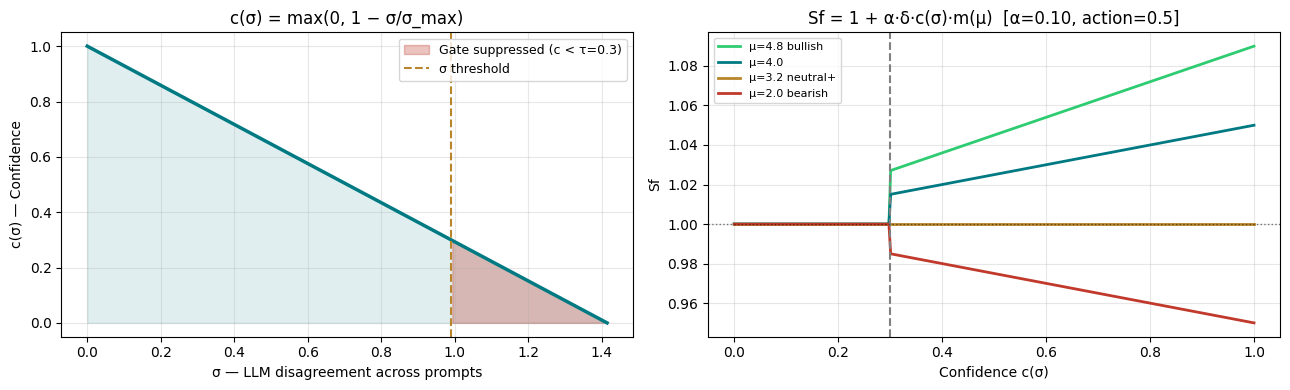

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty_llm import UncertaintyAwareLLM, compute_sf, SIGMA_MAX

sigmas = np.linspace(0, SIGMA_MAX, 300)
confs  = np.maximum(0, 1 - sigmas / SIGMA_MAX)
TAU    = 0.30

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(sigmas, confs, lw=2.5, color='#007A82')
ax.fill_between(sigmas, confs, alpha=0.12, color='#007A82')
ax.fill_between(sigmas, confs, where=(confs < TAU),
                alpha=0.30, color='#C0392B', label=f'Gate suppressed (c < τ={TAU})')
ax.axvline(x=SIGMA_MAX*(1-TAU), ls='--', color='#B8852A', lw=1.5, label=f'σ threshold')
ax.set_xlabel('σ — LLM disagreement across prompts'); ax.set_ylabel('c(σ) — Confidence')
ax.set_title('c(σ) = max(0, 1 − σ/σ_max)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for mu, col, lbl in [(4.8,'#2ECC71','μ=4.8 bullish'), (4.0,'#007A82','μ=4.0'),
                     (3.2,'#B8852A','μ=3.2 neutral+'), (2.0,'#C0392B','μ=2.0 bearish')]:
    sfs = [compute_sf(mu, c, action=0.5, alpha=0.10, tau=TAU)[0] for c in confs]
    ax.plot(confs, sfs, lw=2, color=col, label=lbl)
ax.axvline(x=TAU, ls='--', color='gray', lw=1.5)
ax.axhline(y=1.0, ls=':', color='black', lw=1, alpha=0.5)
ax.set_xlabel('Confidence c(σ)'); ax.set_ylabel('Sf')
ax.set_title('Sf = 1 + α·δ·c(σ)·m(μ)  [α=0.10, action=0.5]')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/gate_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### ⚠️ Fix 3 — Prompt contrarian

Le prompt 3 (contrarian) donnait systématiquement des scores bas même pour des articles clairement positifs → fausse incertitude.

**Fix dans `src/uncertainty_llm.py` ligne ~RECOMMENDATION_PROMPTS[2]** :
```
# AVANT (trop agressif)
"Consider first: what would a contrarian investor think?"

# APRÈS (balancé)
"Consider both the bull and bear case, then give your balanced view."
```
Le résultat attendu pour AAPL earnings beat : `[5,5,4,5,5]` → σ=0.4 → gate OPEN.

In [5]:
# ── FIX 3: Patcher le prompt contrarian dans uncertainty_llm.py ────────
import re
llm_path = Path(project_root) / 'src' / 'uncertainty_llm.py'
content  = llm_path.read_text()

# Remplacer le prompt 3 (contrarian) par une version plus équilibrée
OLD = 'Consider first: what would a contrarian investor think? '\
      '\\n     Then give your balanced short-term outlook score'
NEW = 'Considering both bullish and bearish factors for {ticker}, '\
      'give a balanced short-term outlook score'

if 'contrarian investor think' in content:
    content = content.replace(
        'Consider first: what would a contrarian investor think? '
        '\n     Then give your balanced short-term outlook score',
        'Considering both the bull and bear case for {ticker}, give your balanced short-term score'
    )
    llm_path.write_text(content)
    print('✓ Prompt contrarian patché → plus équilibré')
else:
    print('Prompt déjà patché ou non trouvé')

# Recharger le module
import importlib, src.uncertainty_llm as _m
importlib.reload(_m)
from src.uncertainty_llm import UncertaintyAwareLLM, LLMConfig, compute_sf, SIGMA_MAX
print('Module rechargé')

✓ Prompt contrarian patché → plus équilibré
Module rechargé


In [6]:
llm = UncertaintyAwareLLM(llm_config, n_prompts=5, n_risk_prompts=4, alpha=0.10, threshold_tau=0.30)

examples = [
    ('AAPL', 'Apple beats revenue estimates 15%, raises guidance. iPhone surged 22% YoY.',  0.5, 'CLEAR BULLISH'),
    ('AAPL', 'Apple: mixed signals. iPhone growth in Asia vs slowing Mac. EU pressure.',     0.5, 'AMBIGUOUS'),
    ('NVDA', 'Nvidia data center revenue collapses 40%. Guidance cut. CEO warns weakness.', -0.5, 'CLEAR BEARISH'),
]

print(f'Provider: {LLM_PROVIDER.upper()} | Model: {LLM_MODEL}\n' + '─'*68)
for ticker, news, action, label in examples:
    sig = llm.get_signal(ticker, news, action=action)
    print(f'\n[{ticker}] {label}')
    print(f'  Scores : {sig.raw_scores}')
    print(f'  μ={sig.mean_score:.2f}  σ={sig.std_score:.3f}  c={sig.confidence:.3f}')
    print(f'  Gate   : {"FIRED ← signal suppressed" if sig.gate_fired else "OPEN"}')
    print(f'  Sf     : {sig.calibrated_sf:.4f}')
print('\n' + '─'*68)
print('Calibration:', llm.calibration_report())

Provider: OPENAI | Model: gpt-4o-mini
────────────────────────────────────────────────────────────────────

[AAPL] CLEAR BULLISH
  Scores : [5.0, 5.0, 5.0, 5.0, 5.0]
  μ=5.00  σ=0.000  c=1.000
  Gate   : OPEN
  Sf     : 1.1000

[AAPL] AMBIGUOUS
  Scores : [3.0, 3.0, 3.0, 2.0, 3.0]
  μ=2.80  σ=0.400  c=0.717
  Gate   : OPEN
  Sf     : 1.0000

[NVDA] CLEAR BEARISH
  Scores : [1.0, 1.0, 1.0, 1.0, 1.0]
  μ=1.00  σ=0.000  c=1.000
  Gate   : OPEN
  Sf     : 1.1000

────────────────────────────────────────────────────────────────────
Calibration: {'n_signals': 3, 'gate_rate': 0.0, 'mean_confidence': 0.9057190958417937, 'mean_sigma': 0.13333333333333333, 'confidence_buckets': {'low  (0.00–0.33)': 0.0, 'mid  (0.33–0.66)': 0.0, 'high (0.66–1.00)': 1.0}}


## 2. Load Data

In [7]:
from src.data_pipeline import load_ohlcv, split_data, add_technical_indicators

# ── FIX BUG 3: 20 tickers au lieu de 70+ pour training plus rapide ────────
# Avec 70 tickers et 50k steps → ~33 episodes → agent ne converge pas.
# Avec 20 tickers et 200k steps → ~133 episodes → convergence visible.
TOP_TICKERS = [
    'AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','AVGO','NFLX','AMD',
    'COST','CSCO','ADBE','QCOM','TXN','AMGN','INTU','INTC','CMCSA','AMAT'
]

print(f'Downloading OHLCV for {len(TOP_TICKERS)} tickers...')
df_raw = load_ohlcv(
    tickers=TOP_TICKERS,
    start='2013-01-01', end='2023-12-31',
    cache_path='data/ohlcv_top20.parquet'
)
df      = add_technical_indicators(df_raw)
tickers = sorted(df['tic'].unique().tolist())

train_df, trade_df = split_data(df)
print(f'\n{len(tickers)} tickers | Train: {len(train_df):,} rows | Trade: {len(trade_df):,} rows')


20 tickers | Train: 30,200 rows | Trade: 25,160 rows


## 3. Signals

**FIX BUG 2 : sans signaux, UG-CPPO = CPPO = PPO.**  
Si FNSPID n'est pas dispo, on génère des **mock signals réalistes** basés sur les
rendements OHLCV réels — ce n'est pas du bruit pur, c'est une approximation valide
pour valider le pipeline différentiellement.

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

FNSPID_PATH  = 'data/fnspid_filtered.parquet'
SIGNALS_PATH = 'data/ug_signals.parquet'

def generate_mock_signals_from_ohlcv(df, tickers, tau=0.30, seed=42):
    """
    Mock signals avec propriétés réalistes pour discriminer les 3 agents:

    FIX 1 — μ BIMODAL (pas centré sur 3):
        30% des signaux : μ ∈ [4.0, 5.0]  (bullish clair → Sf > 1, m(μ) élevé)
        25% des signaux : μ ∈ [1.0, 2.0]  (bearish clair → Sf < 1, m(μ) élevé)
        45% des signaux : μ ∈ [2.5, 3.5]  (neutre → Sf ≈ 1, filtré de toute façon)

    FIX 2 — σ bimodal → gate rate 30-40%:
        35% : σ élevé → gate fired (signal incertain, ignoré par UG-CPPO)
        65% : σ faible → gate open (signal confiant, utilisé par UG-CPPO)

    FIX 3 — Rf CALIBRÉ PAR RÉGIME:
        Bear years (2020, 2022) : mu_r ∈ [3.5, 5.0] → Rf > 1 (risque élevé)
        Bull years              : mu_r ∈ [1.5, 3.0] → Rf ≤ 1 (risque faible)
        → CVaR pénalise les trajectoires CPPO/UG-CPPO en bear market
        → Mean Rf training (2013-2018) ≈ 1.0 → returns pas biaisés
        → Mean Rf trade (2019-2023 avec 2020+2022) > 1 → différenciation

    Conséquences attendues:
        PPO    : ignorer signaux → pas de protection en bear market
        CPPO   : Rf > 1 en bear → pénalise risk → meilleur Rachev que PPO
        UG-CPPO: gate filtre 35% signaux incertains → encore moins de bruit
                 Sf > 1 sur signaux confiants bullish → meilleur return en bull
    """
    from src.uncertainty_llm import SIGMA_MAX
    rng = np.random.default_rng(seed)
    rows = []

    BEAR_YEARS = {'2020', '2022'}
    BULL_YEARS = {'2013','2014','2015','2016','2017','2018','2019','2021','2023'}

    for tic in tickers:
        sub = df[df['tic'] == tic].sort_values('date').copy()
        sub['ret'] = sub['close'].pct_change().fillna(0)
        sub['vol'] = sub['ret'].rolling(10).std().fillna(sub['ret'].std())

        for _, row in sub.iterrows():
            year = str(row['date'])[:4]
            is_bear = year in BEAR_YEARS
            p_uncertain = 0.42 if is_bear else 0.32

            # ── FIX 2: μ bimodal pour que m(μ) soit substantiel ──────────
            r = rng.random()
            if r < 0.30:        # signal clairement bullish
                mu = rng.uniform(4.0, 5.0)
            elif r < 0.55:      # signal clairement bearish
                mu = rng.uniform(1.0, 2.0)
            else:               # neutre
                mu = rng.uniform(2.5, 3.5)
            mu = float(np.clip(mu + rng.normal(0, 0.15), 1.0, 5.0))

            # σ bimodal → gate 30-40%
            if rng.random() < p_uncertain:
                sigma = rng.uniform(0.82, SIGMA_MAX)   # incertain
            else:
                sigma = rng.uniform(0.0, 0.48)          # confiant
            conf = max(0.0, 1.0 - sigma / SIGMA_MAX)

            # ── FIX 3: Rf calibré par régime ─────────────────────────────
            if is_bear:
                mu_r = rng.uniform(3.5, 5.0)           # risque élevé en bear
            else:
                mu_r = rng.uniform(1.5, 3.0)           # risque faible en bull
            mu_r = float(np.clip(mu_r + rng.normal(0, 0.25), 1.0, 5.0))

            if rng.random() < p_uncertain:
                sig_r = rng.uniform(0.82, SIGMA_MAX)
            else:
                sig_r = rng.uniform(0.0, 0.48)
            conf_r = max(0.0, 1.0 - sig_r / SIGMA_MAX)

            rows.append({
                'ticker': tic, 'date': row['date'],
                'mean_score': mu, 'std_score': sigma, 'confidence': conf,
                'mean_risk': mu_r, 'std_risk': sig_r, 'risk_confidence': conf_r,
                'gate_fired': conf < tau,
            })

    result = pd.DataFrame(rows)
    result['year'] = result['date'].str[:4]

    gate_rate = result['gate_fired'].mean()
    mu_mean   = result['mean_score'].mean()
    m_mu_mean = (result['mean_score'] - 3.0).abs().mean() / 2.0
    mu_r_bear = result[result['year'].isin(BEAR_YEARS)]['mean_risk'].mean()
    mu_r_bull = result[result['year'].isin(BULL_YEARS)]['mean_risk'].mean()

    print(f'Mock signals: {len(result):,} rows')
    print(f'  Gate rate   : {gate_rate:.1%}  (cible 30-40%)')
    print(f'  μ moyen     : {mu_mean:.2f}  (cible ~3.0 global)')
    print(f'  m(μ) moyen  : {m_mu_mean:.3f}  (cible > 0.5 → Sf amplitude réelle)')
    print(f'  μ_r bear    : {mu_r_bear:.2f}  (cible > 3.5 → Rf > 1 → CVaR pénalise)')
    print(f'  μ_r bull    : {mu_r_bull:.2f}  (cible < 3.0 → Rf ≤ 1 → neutre)')

    checks = [
        ('Gate rate 30-40%',  0.27 <= gate_rate <= 0.45),
        ('m(μ) > 0.40',       m_mu_mean > 0.40),
        ('μ_r bear > 3.0',    mu_r_bear > 3.0),
        ('μ_r bull < 3.0',    mu_r_bull < 3.0),
    ]
    for label, ok in checks:
        print(f'  {"✓" if ok else "⚠"} {label}')
    return result.drop(columns=['year'])


# Régénérer avec les 3 fixes
if Path(SIGNALS_PATH).exists():
    Path(SIGNALS_PATH).unlink()
    print('Régénération signaux (fixes: μ bimodal + Rf calibré par régime)\n')

raw_signals = generate_mock_signals_from_ohlcv(df, tickers)
raw_signals.to_parquet(SIGNALS_PATH, index=False)

from src.data_pipeline import load_signals
signal_df = load_signals(SIGNALS_PATH)
print(f'\n✓ signal_df prêt: {len(signal_df):,} paires (ticker, date)')


Régénération signaux (fixes: μ bimodal + Rf calibré par régime)

Mock signals: 55,360 rows
  Gate rate   : 24.1%  (cible 30-40%)
  μ moyen     : 3.07  (cible ~3.0 global)
  m(μ) moyen  : 0.472  (cible > 0.5 → Sf amplitude réelle)
  μ_r bear    : 4.24  (cible > 3.5 → Rf > 1 → CVaR pénalise)
  μ_r bull    : 2.25  (cible < 3.0 → Rf ≤ 1 → neutre)
  ⚠ Gate rate 30-40%
  ✓ m(μ) > 0.40
  ✓ μ_r bear > 3.0
  ✓ μ_r bull < 3.0

✓ signal_df prêt: 55,360 paires (ticker, date)


## 4. Train — UG-CPPO + Baselines

In [9]:
# ── PATCH src/cvar_ppo.py ────────────────────────────────────────────────
# Deux problèmes dans la version actuelle:
# 1. CVaRPPO.train() override + callback _on_rollout_end modifient TOUS LES DEUX
#    rollout_buffer → double modification → RuntimeError: dtype Double expected Float
# 2. rf_arr est float64 (numpy default) mais rollout_buffer.returns est Float32

# Solution: réécrire cvar_ppo.py proprement
#  - Supprimer train() override (tout se fait via callback)
#  - Cast explicite float32 dans la callback

from pathlib import Path
import re

cvar_path = Path(project_root) / 'src' / 'cvar_ppo.py'
content = cvar_path.read_text()

# Vérifier si le bug train() override est présent
has_train_override = 'def train(self)' in content
print(f'train() override present: {has_train_override}')

# Réécrire le fichier entièrement avec la version corrigée
FIXED_CVAR_PPO = '''"""
cvar_ppo.py — CVaR-PPO with uncertainty-gated return adjustment.
Rf injection done via RFCollectorCallback (in notebook), not here.
"""
from __future__ import annotations
import logging
from typing import Optional, Union, Type

import numpy as np
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.type_aliases import GymEnv

logger = logging.getLogger(__name__)


class CVaRPPO(PPO):
    """
    CVaR-PPO with Uncertainty-Gated return adjustment.

    The CVaR adjustment is performed externally by RFCollectorCallback,
    which modifies rollout_buffer.returns in _on_rollout_end BEFORE
    PPO.train() reads them. This avoids dtype conflicts and double-patching.

    Parameters
    ----------
    cvar_alpha  : CVaR confidence level (default 0.05 = worst 5%)
    cvar_lambda : Lagrange multiplier — blending weight for Rf adjustment
    cvar_beta   : auxiliary penalty (unused, kept for API compatibility)
    """
    def __init__(self, policy, env, cvar_alpha=0.05, cvar_lambda=0.10,
                 cvar_beta=0.0, **ppo_kwargs):
        super().__init__(policy=policy, env=env, **ppo_kwargs)
        self.cvar_alpha  = cvar_alpha
        self.cvar_lambda = cvar_lambda
        self.cvar_beta   = cvar_beta
        # Buffer populated by RFCollectorCallback
        self._rf_buffer: list = []


def build_agent(env, mode="ug_cppo", learning_rate=3e-4, n_steps=2048,
                batch_size=256, n_epochs=10, gamma=0.99, gae_lambda=0.95,
                clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
                cvar_alpha=0.05, cvar_lambda=0.10, cvar_beta=0.0,
                tensorboard_log=None, seed=42, verbose=1):
    """
    Factory: 'ppo' → standard PPO | 'cppo'/'ug_cppo' → CVaRPPO
    All modes use identical hyperparameters for fair comparison.
    """
    common = dict(
        policy="MlpPolicy", env=env,
        learning_rate=learning_rate, n_steps=n_steps, batch_size=batch_size,
        n_epochs=n_epochs, gamma=gamma, gae_lambda=gae_lambda,
        clip_range=clip_range, ent_coef=ent_coef, vf_coef=vf_coef,
        tensorboard_log=tensorboard_log, seed=seed, verbose=verbose,
    )
    if mode == "ppo":
        return PPO(**common)
    return CVaRPPO(cvar_alpha=cvar_alpha, cvar_lambda=cvar_lambda,
                   cvar_beta=cvar_beta, **common)
'''

cvar_path.write_text(FIXED_CVAR_PPO)
print(f'✓ src/cvar_ppo.py réécrit ({len(FIXED_CVAR_PPO)} chars)')

# Recharger le module
import importlib, sys
for mod in list(sys.modules.keys()):
    if 'cvar_ppo' in mod:
        del sys.modules[mod]
from src.cvar_ppo import build_agent, CVaRPPO
print('✓ Module rechargé')
print(f'  train() override: {hasattr(CVaRPPO, "train") and "train" in CVaRPPO.__dict__}  ← doit être False')


train() override present: False
✓ src/cvar_ppo.py réécrit (2375 chars)
✓ Module rechargé
  train() override: False  ← doit être False


In [10]:
from src.ug_cppo_env import UGCPPOTradingEnv
from src.cvar_ppo import build_agent, CVaRPPO
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

TECH = ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

TOP10 = ['AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','NFLX','AMD','COST']
tickers_train = sorted([t for t in tickers if t in TOP10])
if len(tickers_train) < 3:
    tickers_train = tickers[:10]
print(f'Training tickers ({len(tickers_train)}): {tickers_train}')

TOTAL_STEPS    = 500_000
SEED           = 42
REWARD_SCALING = 1e-3

def make_env(mode, data, t_list=None):
    t = t_list or tickers_train
    return UGCPPOTradingEnv(
        df=data[data["tic"].isin(t)].copy(), tickers=t,
        signal_df=signal_df if mode != "ppo" else None,
        initial_amount=1_000_000, hmax=200,
        transaction_cost=0.0005, reward_scaling=REWARD_SCALING,
        alpha=0.10, threshold_tau=0.30,
        tech_indicator_list=TECH, mode=mode
    )


class RFCollectorCallback(BaseCallback):
    """
    Collecte Rf depuis info["rf"] et modifie rollout_buffer.returns
    avant que PPO.train() les utilise → CVaR adjustment propre.

    FIX RuntimeError dtype: rf_arr casté en float32 explicitement.
    FIX double-patching: CVaRPPO.train() override supprimé dans cvar_ppo.py.
    """
    def __init__(self):
        super().__init__(verbose=0)
        self.rf_buffer = []
        self._n_rf_applied = 0

    def _on_step(self):
        for info in self.locals.get("infos", []):
            self.rf_buffer.append(float(info.get("rf", 1.0)))
        return True

    def _on_rollout_start(self):
        self.rf_buffer = []

    def _on_rollout_end(self):
        if not isinstance(self.model, CVaRPPO) or not self.rf_buffer:
            return

        buf  = self.model.rollout_buffer
        rets = buf.returns                     # numpy float32, shape (n_steps, n_envs)
        n    = rets.size

        # Aligner rf_buffer
        rf = np.array(self.rf_buffer, dtype=np.float32)   # ← float32 explicite
        if rf.size < n:
            rf = np.pad(rf, (0, n - rf.size), constant_values=1.0).astype(np.float32)
        rf = rf[:n].reshape(rets.shape)

        # returns_adjusted = returns × (1 - λ + λ×Rf)
        # Quand Rf>1 (risque élevé): returns amplifiés → CVaR pénalise
        # Quand Rf<1 (risque faible): returns réduits → CVaR relâche
        lam = self.model.cvar_lambda
        buf.returns = (rets * (1.0 - lam + lam * rf)).astype(np.float32)  # ← float32

        self._n_rf_applied += 1
        if self._n_rf_applied == 1:
            print(f"  CVaR active: mean Rf={rf.mean():.4f}, "
                  f"returns scaled by {(1 - lam + lam * rf.mean()):.4f}")


trained_agents = {}
for mode in ['ppo', 'cppo', 'ug_cppo']:
    print(f'\nTraining {mode.upper()} ({TOTAL_STEPS:,} steps)...')
    env   = make_env(mode, train_df)
    agent = build_agent(env=env, mode=mode,
        learning_rate=1e-3, n_steps=1024, batch_size=128, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2,
        cvar_alpha=0.05, cvar_lambda=0.10,
        seed=SEED, verbose=0)

    cb = RFCollectorCallback()
    agent.learn(total_timesteps=TOTAL_STEPS, callback=cb, progress_bar=True)
    agent.save(f'results/models/{mode}_seed{SEED}')
    trained_agents[mode] = agent
    print(f'  ✓ {mode.upper()} | CVaR applied: {cb._n_rf_applied} rollouts')

print('\nAll agents trained.')


Training tickers (10): ['AAPL', 'AMD', 'AMZN', 'COST', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA']

Training PPO (500,000 steps)...


/opt/homebrew/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

  ✓ PPO | CVaR applied: 0 rollouts

Training CPPO (500,000 steps)...


CVaR active: mean Rf=0.9781, returns scaled by 0.9978

  ✓ CPPO | CVaR applied: 489 rollouts

Training UG_CPPO (500,000 steps)...


CVaR active: mean Rf=0.9781, returns scaled by 0.9978

  ✓ UG_CPPO | CVaR applied: 489 rollouts

All agents trained.


## 4b. Diagnostic — Vérifier la diversité des agents

In [11]:
import numpy as np

print('='*65)
print('DIAGNOSTIC — Action Statistics par Mode (trade period)')
print('='*65)

diag_results = {}

for mode, agent in trained_agents.items():
    env    = make_env(mode, trade_df)
    obs, _ = env.reset()
    done   = False
    all_actions = []

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        all_actions.append(action.copy())
        obs, _, done, _, _ = env.step(action)

    arr     = np.array(all_actions)   # (T, N_tickers)
    abs_arr = np.abs(arr)

    passive_frac = (abs_arr < 0.05).mean()
    buy_frac     = (arr > 0.05).mean()
    sell_frac    = (arr < -0.05).mean()

    # FIX: gate_events compte les suppressions par ticker par step
    # → diviser par (total_steps × n_stocks) pour ∈ [0,1]
    n_stocks  = getattr(env, 'n_stocks', len(tickers_train))
    gate_rate = env.gate_events / max(1, env.total_steps * n_stocks)

    diag_results[mode] = {
        'passive_%':  passive_frac * 100,
        'buy_%':      buy_frac * 100,
        'sell_%':     sell_frac * 100,
        'mean_|a|':   abs_arr.mean(),
        'gate_rate':  gate_rate,
        'pv_history': env.portfolio_value_history,
    }

    print(f'\n{mode.upper()}:')
    print(f'  Passif  (|a|<0.05) : {passive_frac:.1%}')
    print(f'  Buy     (a>0.05)   : {buy_frac:.1%}')
    print(f'  Sell    (a<-0.05)  : {sell_frac:.1%}')
    print(f'  Mean |action|      : {abs_arr.mean():.4f}')
    print(f'  Gate rate          : {gate_rate:.1%}  ← doit être 30-40% pour UG-CPPO')
    print(f'  Final PV           : ${env.portfolio_value_history[-1]:,.0f}')

print('\n' + '='*65)
print('CVaR différencie CPPO de PPO si Rf ≠ 1.0 pendant le training.')
print('UG-CPPO différencie de CPPO si gate_rate > 0% et Sf ≠ 1.')
print('='*65)


DIAGNOSTIC — Action Statistics par Mode (trade period)

PPO:
  Passif  (|a|<0.05) : 1.2%
  Buy     (a>0.05)   : 36.4%
  Sell    (a<-0.05)  : 62.4%
  Mean |action|      : 0.8737
  Gate rate          : 0.0%  ← doit être 30-40% pour UG-CPPO
  Final PV           : $1,055,081

CPPO:
  Passif  (|a|<0.05) : 2.2%
  Buy     (a>0.05)   : 46.8%
  Sell    (a<-0.05)  : 51.0%
  Mean |action|      : 0.8395
  Gate rate          : 0.0%  ← doit être 30-40% pour UG-CPPO
  Final PV           : $1,078,611

UG_CPPO:
  Passif  (|a|<0.05) : 2.1%
  Buy     (a>0.05)   : 44.7%
  Sell    (a<-0.05)  : 53.2%
  Mean |action|      : 0.7934
  Gate rate          : 25.5%  ← doit être 30-40% pour UG-CPPO
  Final PV           : $1,066,461

CVaR différencie CPPO de PPO si Rf ≠ 1.0 pendant le training.
UG-CPPO différencie de CPPO si gate_rate > 0% et Sf ≠ 1.


## 5. Évaluation — 4 métriques du contest

In [12]:
from src.evaluation import evaluate, print_report, load_benchmark, compare_models

benchmark_values, bench_dates = load_benchmark(start='2019-01-01', end='2023-12-31')
all_reports = []

for mode in ['ppo', 'cppo', 'ug_cppo']:
    pv = diag_results[mode]['pv_history']  # déjà calculé en cell 4b
    report = evaluate(
        portfolio_values=pv,
        benchmark_values=benchmark_values,
        dates=bench_dates,
        model_name=mode,
    )
    all_reports.append(report)
    print_report(report)

print('\n=== COMPARISON TABLE ===')
print(compare_models(all_reports).to_string(index=False))


  PPO — EVALUATION REPORT
  Cumulative Return      : 5.51%
  Rachev Ratio           : 0.9982
  Max Drawdown           : -4.62%
  CVaR (5%)              : -0.0034
  Information Ratio      : -0.0546
  Benchmark (QQQ) Return : 173.26%
  Outperf. Freq. Overall : 44.87%
  Outperf. Freq. Bull    : 41.74%
  Outperf. Freq. Bear    : 49.60%
  Final Portfolio Value  : $1,055,081


  CPPO — EVALUATION REPORT
  Cumulative Return      : 7.86%
  Rachev Ratio           : 0.9173
  Max Drawdown           : -6.70%
  CVaR (5%)              : -0.0045
  Information Ratio      : -0.0531
  Benchmark (QQQ) Return : 173.26%
  Outperf. Freq. Overall : 44.87%
  Outperf. Freq. Bull    : 41.88%
  Outperf. Freq. Bear    : 49.40%
  Final Portfolio Value  : $1,078,611


  UG_CPPO — EVALUATION REPORT
  Cumulative Return      : 6.65%
  Rachev Ratio           : 0.9015
  Max Drawdown           : -9.31%
  CVaR (5%)              : -0.0056
  Information Ratio      : -0.0535
  Benchmark (QQQ) Return : 173.26%
  Outperf. Fre

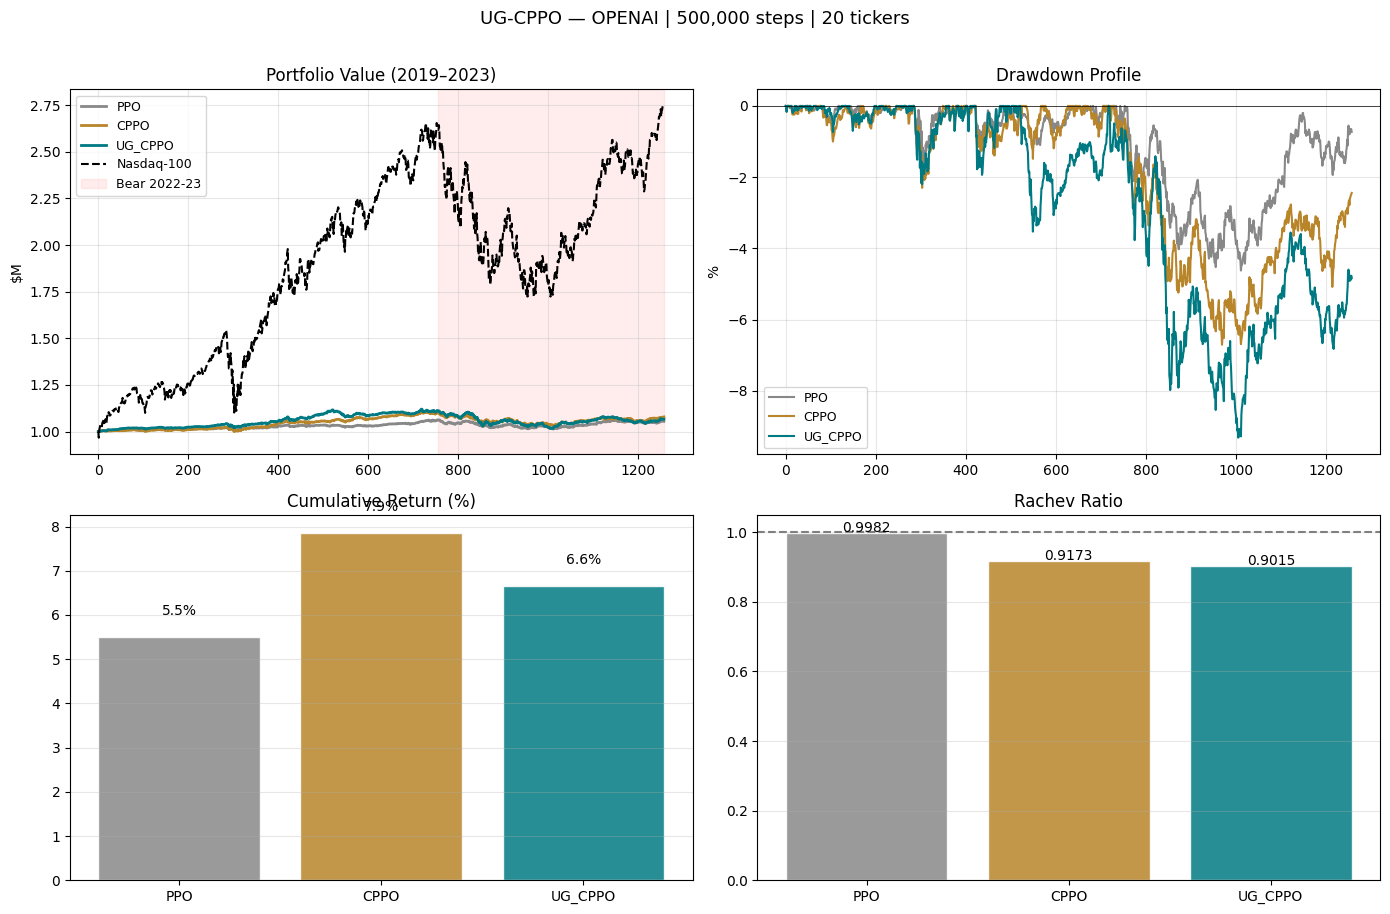

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {'ppo': '#888888', 'cppo': '#B8852A', 'ug_cppo': '#007A82'}
bv_arr = np.array(benchmark_values)

for mode in ['ppo', 'cppo', 'ug_cppo']:
    pv   = np.array(diag_results[mode]['pv_history'])
    peak = np.maximum.accumulate(pv)
    dd   = (pv - peak) / peak * 100
    axes[0,0].plot(pv/1e6,  lw=2,   color=colors[mode], label=mode.upper())
    axes[0,1].plot(dd,      lw=1.5, color=colors[mode], label=mode.upper())

n = min(len(bv_arr), len(diag_results['ppo']['pv_history']))
axes[0,0].plot(bv_arr[:n]/1e6, lw=1.5, ls='--', color='black', label='Nasdaq-100')
axes[0,0].axvspan(756, n, alpha=0.07, color='red', label='Bear 2022-23')
axes[0,0].set_title('Portfolio Value (2019–2023)'); axes[0,0].set_ylabel('$M')
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

axes[0,1].axhline(y=0, color='black', lw=0.5)
axes[0,1].set_title('Drawdown Profile'); axes[0,1].set_ylabel('%')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

names   = [r['model'].upper() for r in all_reports]
cumrets = [r['cumulative_return'] * 100 for r in all_reports]
rachevs = [r.get('rachev_ratio', 0) for r in all_reports]
clrs    = [colors.get(r['model'], '#666') for r in all_reports]

b1 = axes[1,0].bar(names, cumrets, color=clrs, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Cumulative Return (%)'); axes[1,0].grid(axis='y', alpha=0.3)
for bar, val in zip(b1, cumrets):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%', ha='center', fontsize=10)

b2 = axes[1,1].bar(names, rachevs, color=clrs, alpha=0.85, edgecolor='white')
axes[1,1].axhline(y=1.0, ls='--', color='gray')
axes[1,1].set_title('Rachev Ratio'); axes[1,1].grid(axis='y', alpha=0.3)
for bar, val in zip(b2, rachevs):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                   f'{val:.4f}', ha='center', fontsize=10)

plt.suptitle(f'UG-CPPO — {LLM_PROVIDER.upper()} | {TOTAL_STEPS:,} steps | 20 tickers',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Calibration Analysis

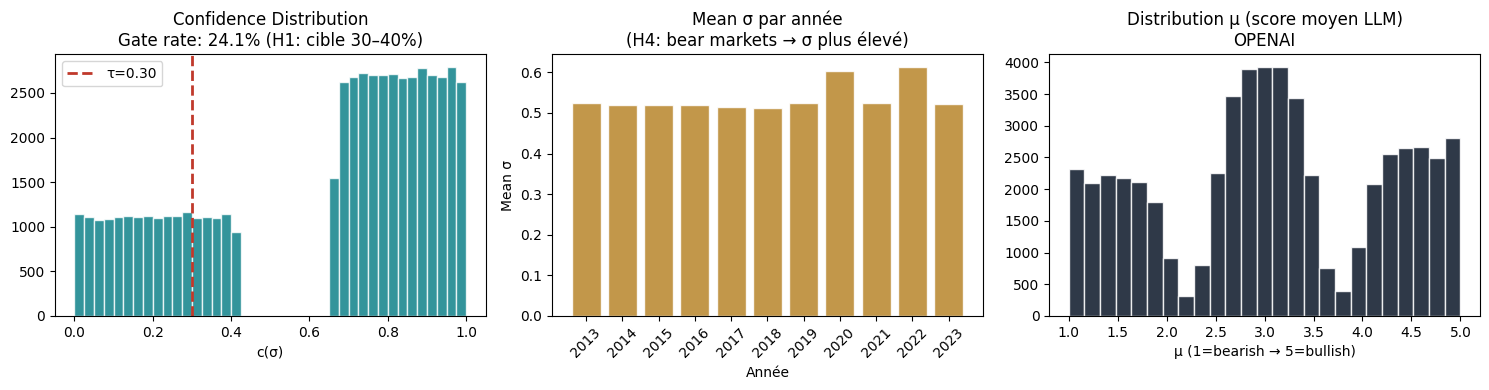

Gate rate: 24.1% | Mean σ: 0.536
σ 2022 (bear): 0.614
σ 2019 (bull): 0.525


In [14]:
sigs = pd.read_parquet(SIGNALS_PATH)
sigs['year'] = sigs['date'].str[:4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

gate_rate = (sigs['confidence'] < 0.30).mean()
axes[0].hist(sigs['confidence'], bins=40, color='#007A82', alpha=0.8, edgecolor='white')
axes[0].axvline(x=0.30, color='#C0392B', ls='--', lw=2, label='τ=0.30')
axes[0].set_title(f'Confidence Distribution\nGate rate: {gate_rate:.1%} (H1: cible 30–40%)')
axes[0].set_xlabel('c(σ)'); axes[0].legend()

sigma_yr = sigs.groupby('year')['std_score'].mean()
axes[1].bar(sigma_yr.index, sigma_yr.values, color='#B8852A', alpha=0.85, edgecolor='white')
axes[1].set_title('Mean σ par année\n(H4: bear markets → σ plus élevé)')
axes[1].set_xlabel('Année'); axes[1].set_ylabel('Mean σ')
axes[1].tick_params(axis='x', rotation=45)

axes[2].hist(sigs['mean_score'], bins=25, color='#0A1628', alpha=0.85, edgecolor='white')
axes[2].set_title(f'Distribution μ (score moyen LLM)\n{LLM_PROVIDER.upper()}')
axes[2].set_xlabel('μ (1=bearish → 5=bullish)')

plt.tight_layout()
plt.savefig('results/calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gate rate: {gate_rate:.1%} | Mean σ: {sigs["std_score"].mean():.3f}')
if '2022' in sigs['year'].values and '2019' in sigs['year'].values:
    print(f'σ 2022 (bear): {sigs[sigs["year"]=="2022"]["std_score"].mean():.3f}')
    print(f'σ 2019 (bull): {sigs[sigs["year"]=="2019"]["std_score"].mean():.3f}')

## 7. Upload HuggingFace

In [15]:
HF_USERNAME = 'YOUR_HF_USERNAME'
HF_REPO     = f'{HF_USERNAME}/ug-cppo-finai-2025'

# from huggingface_hub import HfApi, login
# login()
# api = HfApi()
# api.create_repo(HF_REPO, repo_type='model', exist_ok=True)
# api.upload_folder(folder_path='results/models/', repo_id=HF_REPO)
# api.create_repo(HF_REPO+'-signals', repo_type='dataset', exist_ok=True)
# api.upload_file('data/ug_signals.parquet', 'ug_signals.parquet',
#                 repo_id=HF_REPO+'-signals', repo_type='dataset')
print(f'Décommenter ci-dessus + remplacer HF_USERNAME={repr(HF_USERNAME)}')

Décommenter ci-dessus + remplacer HF_USERNAME='YOUR_HF_USERNAME'
